In [ ]:
import os 
import glob
import warnings
import random
import numpy as np 
from tqdm import tqdm
from utils.plots import *
from rl.agent import TDLearning,TDLearning_V
from utils.path import PathConfig,FigureWithData
import importlib

seed_value = 1234
warnings.filterwarnings("ignore")
np.random.seed(seed_value)
random.seed(seed_value)


fig_dir = os.path.join('figures', 'figure_S1')
data_fig_dir = os.path.join('data', 'source_data', 'figure_S1')
os.makedirs(fig_dir, exist_ok=True)
os.makedirs(data_fig_dir, exist_ok=True)

## Reinforcement learning simulations 


Types of simulations  (`simulation_type`) are {`eta_sampling_`, `eta_nosampling_nodistr_`, `eta_nosampling_nodistr_`}


`eta_sampling_`: TD learning with DRL performing sampling for the computation of next step value predictors. 
$$
\delta_{i,t} = r_t + \gamma \cdot \hat{z}(s_{t+1}) - V_i(s_t)\\
\hat{\delta}_{i,t} ~~ = ~~~\tau_i \cdot \delta_{i,t} ~~~... ~~~\text{if} ~ \delta_{i,t} >0 \\
\hat{\delta}_{i,t}  = (1-\tau_i) \cdot \delta_{i,t} ~~~... ~~~\text{if} ~ \delta_{i,t} \leq 0
$$

- Where $ \hat{z}(s_{t+1})$ is a sample from the distribution defined by the set of $\hat{V}_i(s_{t+1})$
- Update of value:
$$
P_i(s_t) \leftarrow P_i(s_t) + \eta \cdot |\hat{\delta}_i(t)| - \beta \cdot P_i(s_t) ~~~... ~~~\text{if} ~ \delta_{i,t} >0\\
N_i(s_t) \leftarrow N_i(s_t) + (1-\eta) \cdot |\hat{\delta}_i(t)| - \beta \cdot N_i(s_t) ~~~... ~~~\text{if} ~ \delta_{i,t} \leq 0 \\
\hat{V}_i(s_t) = P_i(s_t) - N_i(s_t)
$$  

`eta_nosampling_nodistr_`: TD learning not DRL using the mean across  $\tau s $  
$$
\delta_{t} = r_t + \gamma \cdot V(s_{t+1}) - V(s_t)\\
\hat{\delta}_{t} ~~ = ~~~\hat{\tau} \cdot \delta_{t} ~~~... ~~~\text{if} ~ \delta_{t} >0 \\
\hat{\delta}_{t}  =(1-\hat{\tau}) \cdot \delta_{t} ~~~... ~~~\text{if} ~ \delta_{t} \leq 0
$$

- Where $ \hat{\tau}$ is the mean of the $\tau_i$ across the population of each group
- Update of value:
$$
P(s_t) \leftarrow P(s_t) + \eta \cdot |\hat{\delta}_i(t)| - \beta \cdot P(s_t) ~~~... ~~~\text{if} ~ \delta_{t} >0\\
N(s_t) \leftarrow N(s_t) + (1-\eta) \cdot |\hat{\delta}_i(t)| - \beta \cdot N(s_t) ~~~... ~~~\text{if} ~ \delta_{t} \leq 0 \\
\hat{V}(s_t) = P(s_t) - N(s_t)
$$  


`eta_nosampling_`: TD learning with DRL without performing sampling for the computation of next step value predictors
$$
\delta_{i,t} = r_t + \gamma \cdot \hat{V}_i(s_{t+1}) - V_i(s_t)\\
\hat{\delta}_{i,t} ~~ = ~~~\tau_i \cdot \delta_{i,t} ~~~... ~~~\text{if} ~ \delta_{i,t} >0 \\
\hat{\delta}_{i,t}  = (1-\tau_i) \cdot \delta_{i,t} ~~~... ~~~\text{if} ~ \delta_{i,t} \leq 0
$$

- Where $ \hat{V}_i(s_{t+1})$  is the value predictor in the next time step
- Update of value:
$$
P_i(s_t) \leftarrow P_i(s_t) + \eta \cdot |\hat{\delta}_i(t)| - \beta \cdot P_i(s_t) ~~~... ~~~\text{if} ~ \delta_{i,t} >0\\
N_i(s_t) \leftarrow N_i(s_t) + (1-\eta) \cdot |\hat{\delta}_i(t)| - \beta \cdot N_i(s_t) ~~~... ~~~\text{if} ~ \delta_{i,t} \leq 0 \\
\hat{V}_i(s_t) = P_i(s_t) - N_i(s_t)
$$ 

**Note**: To plot and use the present notebook the user needs to download the data inside `analysis` folder of the OSF repository. Look at  `download_data` for the code to do this.

In [2]:
paths = PathConfig()
alpha_pos_da = np.linspace(.1,.9,20)[None,:]
alpha_neg_da = 1-alpha_pos_da
taus_da= (alpha_pos_da)/(alpha_pos_da+alpha_neg_da)
alpha_pos_rec = np.linspace(.1,.9,10)[:,None]
alpha_neg_rec = 1- alpha_pos_rec
taus_rec= (alpha_pos_rec)/(alpha_pos_rec+alpha_neg_rec)
taus_prod = (alpha_pos_rec@alpha_pos_da)/((alpha_pos_rec@alpha_pos_da)+(alpha_neg_rec@alpha_neg_da))


In [30]:
# Mechanism 1 in risk sensitive TD learning
simulation_type = 'eta_nosampling_' 
tau_rec =  0.5 
tau_da = 0.5
beta_v = [0.001,0.002,0.005,0.01,0.02,0.01] 

save_dics_mech1 = dict()
for epsilon_ in tqdm(beta_v):
    taus_ = np.array([tau_da])
    etas =  np.array([tau_rec])
    s = dict()
    s['agent'] = dict()
    s['task'] = dict()
    if simulation_type == 'eta_nosampling_' :
        s['agent']['taus'] =  np.sort(taus_) # needs to be array  np.asarray([np.nanmean(taus_) ]) #  np.sort(taus_)
        s['agent']['do_sampling'] = False
    elif simulation_type == 'eta_nosampling_nodistr_': 
        s['agent']['taus'] =   np.asarray([np.nanmean(taus_) ]) # needs to be array 
        s['agent']['do_sampling'] = False
    elif simulation_type == 'eta_sampling_': 
        s['agent']['taus'] =  np.sort(taus_) # needs to be array  np.asarray([np.nanmean(taus_) ]) #  np.sort(taus_)
        s['agent']['do_sampling'] = True
    
    s['agent']['eta'] = etas
    s['agent']['str_agent'] = ['Eta_' + str(etas[0])]#,'neutral','optimistic']
    s['agent']['epsilon'] = epsilon_
    s['agent']['base_alpha'] = .2
    s['agent']['gamma'] = 1
    
    s['agent']['d1_d2'] = True
    s['task']['prob'] = [[.1, .9],[.5, .5],[.9, .1] ]
    s['task']['mags'] = [[1, 0],[1, 0],[1, 0] ]
    s['task']['percent_per_cs'] = 1/len(s['task']['mags'])*np.ones((len(s['task']['mags']),1))
    s['task']['cs_id'] = [[0,0],[1,1],[2,2]]
    s['task']['str_cs'] = [ '10%','50%','90%' ]
    s['task']['str_task'] = 'drl_6odor'
    s['task']['n_trials'] = 65000
    s['task']['cue_onset'] = 1
    s['task']['cue_dur'] = 1
    s['task']['rew_onset'] = 3
    s['task']['iti_dur'] = 1
    s['task']['n_iterations'] = 1
    s['task']['type'] = 'cue_reward'
    s['task']['seed']=seed_value

    agent = TDLearning(s,random_init=False)
    agent.initialize_results()
    agent.run_task()
    agent.reformat_results()
    save_dic = dict()
    results = dict()
    save_vars = ['distribution_trials_full', 'distribution_g_trials_full', 'distribution_ng_trials_full',  'deltas_trials_full', 
                    'distribution_trials_full2', 'distribution_g_trials_full2', 'distribution_ng_trials_full2',  'deltas_trials_full2', 
                'distribution_ng_trials', 'distribution_g_trials', 'distribution_trials','deltas_trials']
    for ivar in save_vars:
        temp = agent.results[ivar]
        results[ivar] = temp
    save_vars = ['distribution','distribution_g','distribution_ng','samp_distribution','deltas','deltas_trials_raw','distribution_std']
    new_dict = vars(agent)
    for ivar in save_vars:
        results[ivar] = new_dict[ivar]
    agent_dict = dict()
    save_vars=['taus', 'eta', 'str_agent', 'epsilon', 'base_alpha', 'do_sampling', 'gamma',
                'n_cells', 'task_type', 'n_deliv_rew', 'deliv_rew', 'deliv_cs', 'trial_length', 
                'n_trials', 'cs_vector', 'us_vector', 'id_states_per_cs', 'n_types', 'n_tr_max', 
                'i_step_per_cs']
    for ivar in save_vars:
        agent_dict[ivar] = new_dict[ivar]
    save_dic['results'] = results
    save_dic['agent'] = agent_dict
    save_dic['task'] = vars(agent.task)
    save_dic['eta'] = etas
    save_dics_mech1[str(epsilon_)]=save_dic

100%|██████████| 6/6 [00:48<00:00,  8.07s/it]


Saved figure to figures/figure_S1/Figure_S1.pdf
Saved data and stats to data/figure_data/figure_S1/Figure_S1.txt


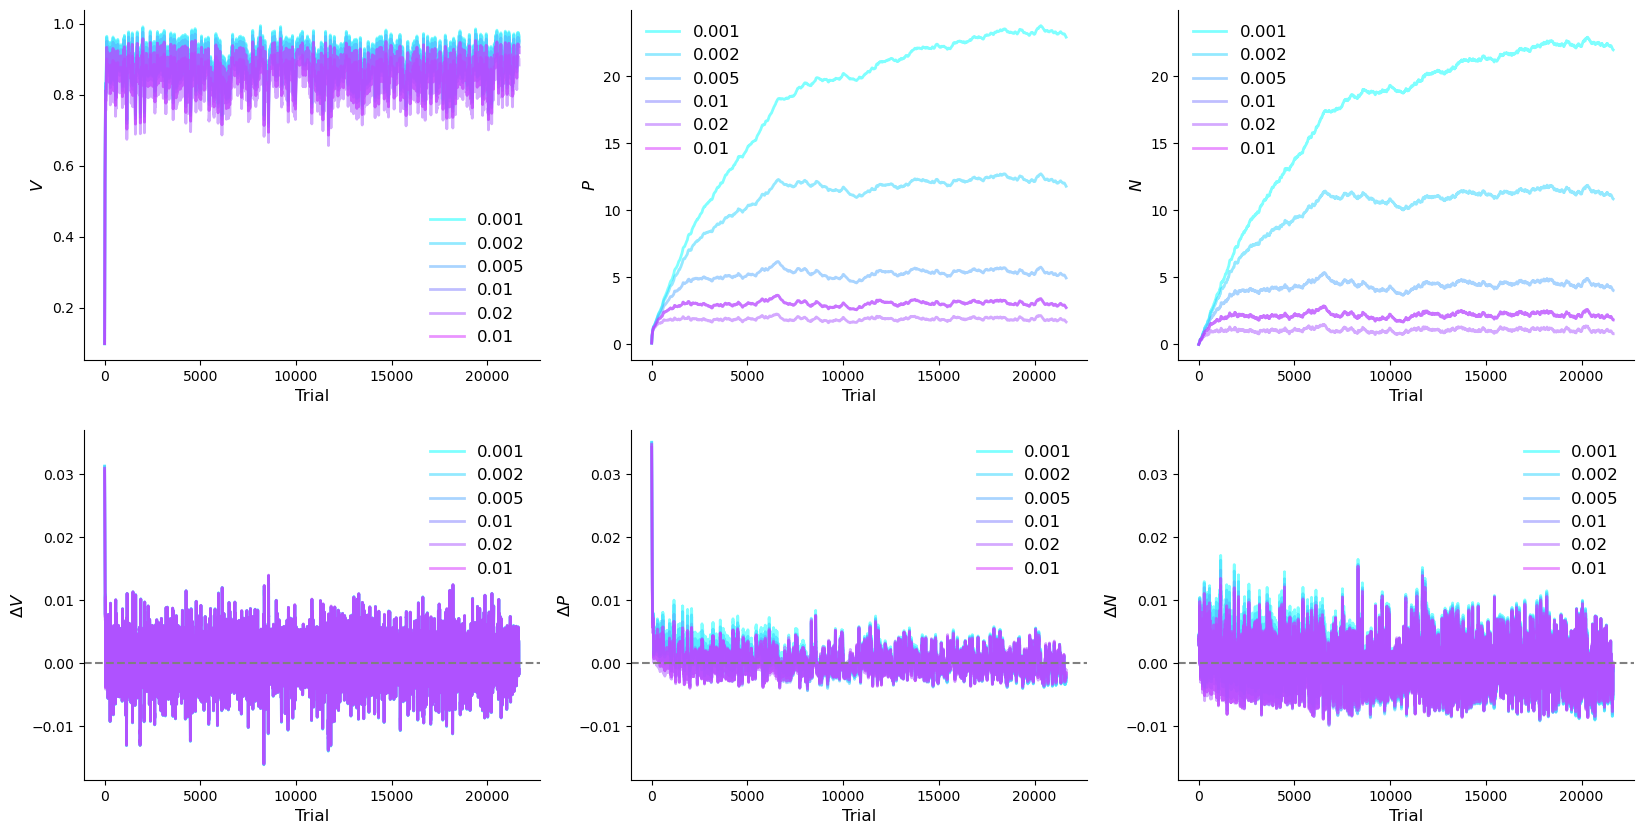

In [33]:
# Plot Supp Fig 5 e-f
from scipy.signal import savgol_filter

idict = save_dics_mech1
taus_i =  taus_rec
ntr_count=-500
id_cue_trtype = [2]
filtsize=31
fig,ax=plt.subplots(2,3,figsize=(20,10))

for (ie,epsilon_) in enumerate(beta_v):
    res = idict[str(epsilon_)]['results']
    ag = idict[str(epsilon_)]['agent']
    gamma_ = ag['gamma']

    v_trial = res['distribution_trials_full2'][0,id_cue_trtype,3,:].flatten() 
    p_trial = res['distribution_g_trials_full2'][0,id_cue_trtype,3,:].flatten()
    n_trial = res['distribution_ng_trials_full2'][0,id_cue_trtype,3,:].flatten()


    ax[0,0].plot(np.arange(len(v_trial)),savgol_filter(v_trial,filtsize,2), alpha=.5,lw=2,color=cm.cool(ie/len(beta_v)),label=str(epsilon_))
    ax[0,1].plot(np.arange(len(p_trial)),savgol_filter(p_trial,filtsize,2), alpha=.5,lw=2,color=cm.cool(ie/len(beta_v)),label=str(epsilon_))
    ax[0,2].plot(np.arange(len(n_trial)),savgol_filter(n_trial,filtsize,2), alpha=.5,lw=2,color=cm.cool(ie/len(beta_v)),label=str(epsilon_))

    ax[1,0].plot(np.arange(len(v_trial)-1),np.diff(savgol_filter(v_trial,filtsize,2)), alpha=.5,lw=2,color=cm.cool(ie/len(beta_v)),label=str(epsilon_))
    ax[1,1].plot(np.arange(len(p_trial)-1),np.diff(savgol_filter(p_trial,filtsize,2)), alpha=.5,lw=2,color=cm.cool(ie/len(beta_v)),label=str(epsilon_))
    ax[1,2].plot(np.arange(len(n_trial)-1),np.diff(savgol_filter(n_trial,filtsize,2)), alpha=.5,lw=2,color=cm.cool(ie/len(beta_v)),label=str(epsilon_))

plot_config(ax[0,0],'Trial',r'$V$',12, True)
plot_config(ax[0,1],'Trial',r'$P$',12, True)
plot_config(ax[0,2],'Trial',r'$N$',12, True)

plot_config(ax[1,0],'Trial',r'$\Delta V$',12, True)
plot_config(ax[1,1],'Trial',r'$\Delta P$',12, True)
plot_config(ax[1,2],'Trial',r'$\Delta N$',12, True)
_=limit_xyaxis(ax[1,:])
_=limit_xyaxis(ax[0,1:])
_= [ia.plot([ia.get_xlim()[0], ia.get_xlim()[1]],[0,0],color='grey',linestyle='--') for ia in ax[1,:]]

# 1. Create the wrapper
fig_data_S1 = FigureWithData(fig)

# 2. Save the V, P, N traces + their derivatives
for ie, epsilon_ in enumerate(beta_v):
    res = idict[str(epsilon_)]['results']
    ag = idict[str(epsilon_)]['agent']
    gamma_ = ag['gamma']

    # Extract and smooth
    v_trial = res['distribution_trials_full2'][0, id_cue_trtype, 3, :].flatten()
    p_trial = res['distribution_g_trials_full2'][0, id_cue_trtype, 3, :].flatten()
    n_trial = res['distribution_ng_trials_full2'][0, id_cue_trtype, 3, :].flatten()

    v_smooth = savgol_filter(v_trial, filtsize, 3)
    p_smooth = savgol_filter(p_trial, filtsize, 3)
    n_smooth = savgol_filter(n_trial, filtsize, 3)

    dv_smooth = np.diff(v_smooth)
    dp_smooth = np.diff(p_smooth)
    dn_smooth = np.diff(n_smooth)

    trial_numbers_v = np.arange(len(v_smooth))
    trial_numbers_dv = np.arange(len(dv_smooth))

    # Save V, P, N smooth
    data_smooth = np.column_stack((trial_numbers_v, v_smooth, p_smooth, n_smooth))
    headers_smooth = ['Trial', 'V_smooth', 'P_smooth', 'N_smooth']
    fig_data_S1.add_data(
        f"Smoothed V, P, N - epsilon={epsilon_}",
        data_smooth,
        headers_smooth
    )

    # Save ΔV, ΔP, ΔN
    data_diff = np.column_stack((trial_numbers_dv, dv_smooth, dp_smooth, dn_smooth))
    headers_diff = ['Trial', 'Delta_V', 'Delta_P', 'Delta_N']
    fig_data_S1.add_data(
        f"Derivatives of V, P, N - epsilon={epsilon_}",
        data_diff,
        headers_diff
    )

# 3. Save everything
fig_data_S1.save(
    base_filename='Figure_S1',
    folder_data= data_fig_dir,
    folder_figures=fig_dir
)